# 07 - Interpretación de modelos para predicción de AKI

## Objetivo
El objetivo de este notebook fue interpretar los modelos entrenados para la predicción temprana de lesión renal aguda, analizando la relevancia de las variables desde dos enfoques complementarios:

- la **regresión logística**, mediante coeficientes y odds ratios
- y el **Random Forest**, mediante importancias relativas de variables

Esta fase tuvo un valor metodológico y clínico importante, ya que permitió traducir el comportamiento interno de los modelos a una lectura más comprensible, útil para la discusión del TFG y para la interpretación prudente de los predictores más influyentes.


### 1. Importar librerías
Se importaron librerías para:

- manipulación de datos (`pandas`, `numpy`)
- visualización (`matplotlib`, `seaborn`)
- carga de modelos guardados (`joblib`)
- reconstrucción del split (`train_test_split`)

Estas librerías eran necesarias para recuperar los modelos entrenados, reconstruir el escenario de entrenamiento y elaborar tablas y gráficos interpretativos.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

FIGURES_DIR="../figures"
RESULTS_DIR="../results"

os.makedirs(FIGURES_DIR,exist_ok=True)
os.makedirs(RESULTS_DIR,exist_ok=True)

print("Carpetas de figures y results listas.")

Carpetas de figures y results listas.


### 2. Carga del dataset final de modelado
Se cargó el archivo `aki_dataset_model_ready.csv`, correspondiente al conjunto final de variables definido en el notebook 04.

Para interpretar correctamente los modelos era necesario partir del mismo conjunto de predictores con el que se realizó el entrenamiento.


In [3]:
file_path = "../data/processed/aki_dataset_model_ready.csv"
df = pd.read_csv(file_path)

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado correctamente.
Filas: 1175
Columnas: 14


### 3. Separación en `X` e `y` y reconstrucción del split
Se realizó nuevamente la separación entre:

- `X`: matriz de predictores
- `y`: variable objetivo

Posteriormente se reconstruyó el mismo split estratificado de entrenamiento y prueba empleado en notebooks anteriores.

In [4]:
target_col = "AKI_48h"
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 4. Carga de modelos entrenados
Se cargaron los modelos previamente almacenados:

- `logreg_pipeline.pkl`
- `rf_pipeline.pkl`

Recuperar los pipelines entrenados permitía acceder directamente a:
- los coeficientes de la regresión logística.
- y las importancias del Random Forest.


In [5]:
logreg_pipeline = joblib.load("../models/logreg_pipeline.pkl")
rf_pipeline = joblib.load("../models/rf_pipeline.pkl")

print("Modelos cargados correctamente.")

Modelos cargados correctamente.


### 5. Definición del orden correcto de variables tras el preprocesamiento

Se reconstruyó manualmente el orden de las variables tal como entraban al modelo después del `ColumnTransformer`.

El orden quedó definido como:

**Variables numéricas**
- `Potasio_mmol_L`
- `Sodio_mmol_L`
- `BaselineCreatinina`

**Variables binarias o enteras**
- `Sexo`
- `EdadAproxIngreso`
- `Edad_ge_65`
- `AINE`
- `IECA`
- `ARAII`
- `DIURETICO`
- `VANCOMICINA`
- `AMINOGLUCOSIDO`
- `N_Farmacos_Riesgo`

Este paso fue fundamental para asignar correctamente cada coeficiente e importancia a su predictor correspondiente. Al utilizar un pipeline con preprocesamiento, el orden de variables internas del modelo no puede asumirse de forma implícita.

Gracias a esta reconstrucción fue posible realizar una interpretación válida y no errónea de los modelos.


In [6]:
numeric_features = [
    "Potasio_mmol_L",
    "Sodio_mmol_L",
    "BaselineCreatinina"
]

binary_or_integer_features = [
    "Sexo",
    "EdadAproxIngreso",
    "Edad_ge_65",
    "AINE",
    "IECA",
    "ARAII",
    "DIURETICO",
    "VANCOMICINA",
    "AMINOGLUCOSIDO",
    "N_Farmacos_Riesgo"
]

feature_order_after_preprocessing = numeric_features + binary_or_integer_features
feature_order_after_preprocessing

['Potasio_mmol_L',
 'Sodio_mmol_L',
 'BaselineCreatinina',
 'Sexo',
 'EdadAproxIngreso',
 'Edad_ge_65',
 'AINE',
 'IECA',
 'ARAII',
 'DIURETICO',
 'VANCOMICINA',
 'AMINOGLUCOSIDO',
 'N_Farmacos_Riesgo']

### 6. Extracción e interpretación de coeficientes de la regresión logística
Se extrajeron los coeficientes de la regresión logística y se construyó una tabla con:

- nombre de la variable
- coeficiente
- valor absoluto del coeficiente
- odds ratio

In [8]:
logreg_model = logreg_pipeline.named_steps["model"]

coef_df = pd.DataFrame({
    "Variable": feature_order_after_preprocessing,
    "Coeficiente": logreg_model.coef_[0]
})

coef_df["Abs_Coeficiente"] = coef_df["Coeficiente"].abs()
coef_df["Odds_Ratio"] = np.exp(coef_df["Coeficiente"])

coef_df.sort_values(by="Abs_Coeficiente", ascending=False)


,Variable,Coeficiente,Abs_Coeficiente,Odds_Ratio
7,IECA,1.415263,1.415263,4.117570
6,AINE,1.317561,1.317561,3.734303
10,VANCOMICINA,-1.251969,1.251969,0.285941
3,Sexo,-0.955955,0.955955,0.384445
11,AMINOGLUCOSIDO,-0.911235,0.911235,0.402027
2,BaselineCreatinina,0.684896,0.684896,1.983566
5,Edad_ge_65,-0.646888,0.646888,0.523673
12,N_Farmacos_Riesgo,0.434097,0.434097,1.543569
8,ARAII,-0.278234,0.278234,0.757120
0,Potasio_mmol_L,-0.173025,0.173025,0.841117


In [9]:
coef_df.to_csv(f"{RESULTS_DIR}/results_07_logreg_coefficients.csv", index=False)

#### Resultados principales
Las variables con mayor peso absoluto en la regresión logística fueron:

- `IECA` → coeficiente = 1.415, odds ratio = 4.118
- `AINE` → coeficiente = 1.318, odds ratio = 3.734
- `VANCOMICINA` → coeficiente = -1.252, odds ratio = 0.286
- `Sexo` → coeficiente = -0.956, odds ratio = 0.384
- `AMINOGLUCOSIDO` → coeficiente = -0.911, odds ratio = 0.402
- `BaselineCreatinina` → coeficiente = 0.685, odds ratio = 1.984

**Justificación**

La regresión logística permite interpretar directamente la asociación entre cada predictor y la probabilidad relativa de pertenecer a la clase positiva, manteniendo constantes el resto de variables del modelo.

**Interpretación**

Los coeficientes positivos indican asociación predictiva positiva con la clase AKI, mientras que los negativos indican asociación inversa dentro del modelo.

No obstante, esta lectura debe realizarse con cautela. Los coeficientes reflejan el comportamiento del modelo dentro de esta cohorte concreta y no constituyen evidencia causal.

Además, en variables con baja frecuencia de exposición, como `VANCOMICINA` o `AMINOGLUCOSIDO`, la magnitud del coeficiente puede ser más inestable debido al tamaño reducido del subgrupo correspondiente.


### 7. Visualización de coeficientes de la regresión logística 
Se generó un gráfico de barras ordenado según el valor del coeficiente para visualizar la dirección y magnitud de las asociaciones de la regresión logística.

**Justificación**
La representación gráfica facilita una lectura más intuitiva del modelo que una tabla numérica aislada.

**Interpretación**
El gráfico permitió apreciar qué variables empujaban la predicción en sentido positivo y cuáles lo hacían en sentido negativo, así como identificar las de mayor peso absoluto dentro del modelo lineal.


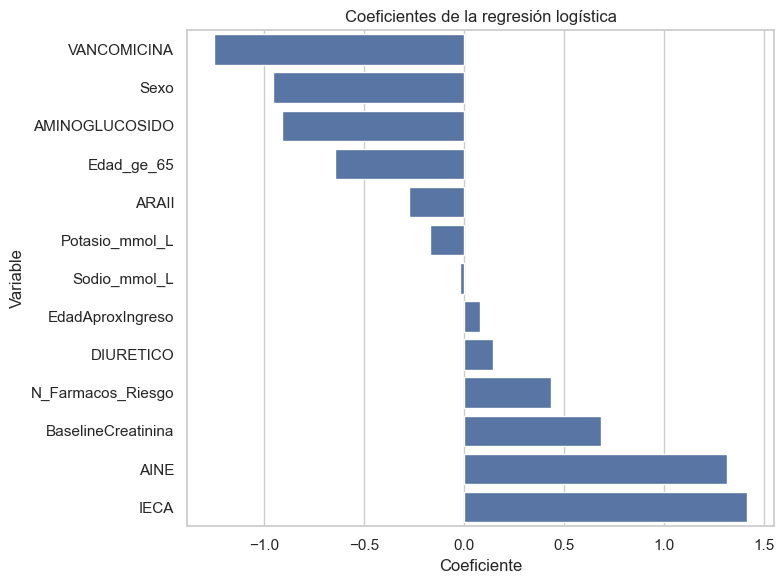

In [10]:
coef_plot_df = coef_df.sort_values(by="Coeficiente", ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_plot_df, x="Coeficiente", y="Variable")
plt.title("Coeficientes de la regresión logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_11_logreg_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

### 8. Interpretación mediante odds ratio
Se calcularon los odds ratios exponenciando los coeficientes de la regresión logística.

**Justificación**
Los odds ratios suelen resultar más intuitivos que los coeficientes crudos, especialmente en contextos clínicos, porque expresan la asociación relativa entre el predictor y la clase positiva.

**Interpretación**
Un odds ratio superior a 1 indica una asociación positiva con AKI dentro del modelo, mientras que un valor inferior a 1 indica asociación inversa.

Entre los resultados más relevantes:
- `IECA` y `AINE` mostraron odds ratios claramente superiores a 1,
- `BaselineCreatinina` mostró un odds ratio cercano a 2,
- algunas variables como `VANCOMICINA` y `AMINOGLUCOSIDO` presentaron odds ratios inferiores a 1, aunque estas asociaciones deben interpretarse con especial prudencia dada su baja frecuencia.

In [11]:
coef_df.sort_values(by="Odds_Ratio", ascending=False)

,Variable,Coeficiente,Abs_Coeficiente,Odds_Ratio
7,IECA,1.415263,1.415263,4.117570
6,AINE,1.317561,1.317561,3.734303
2,BaselineCreatinina,0.684896,0.684896,1.983566
12,N_Farmacos_Riesgo,0.434097,0.434097,1.543569
9,DIURETICO,0.142712,0.142712,1.153397
4,EdadAproxIngreso,0.077839,0.077839,1.080949
1,Sodio_mmol_L,-0.019376,0.019376,0.980810
0,Potasio_mmol_L,-0.173025,0.173025,0.841117
8,ARAII,-0.278234,0.278234,0.757120
5,Edad_ge_65,-0.646888,0.646888,0.523673


### 9. Extracción de importancias de variables del Random Forest
Se extrajeron las importancias relativas de las variables a partir del atributo `feature_importances_` del Random Forest.

In [12]:
rf_model = rf_pipeline.named_steps["model"]

rf_importance_df = pd.DataFrame({
    "Variable": feature_order_after_preprocessing,
    "Importancia": rf_model.feature_importances_
})

rf_importance_df.sort_values(by="Importancia", ascending=False)

,Variable,Importancia
2,BaselineCreatinina,0.262868
4,EdadAproxIngreso,0.188128
1,Sodio_mmol_L,0.149895
0,Potasio_mmol_L,0.148406
12,N_Farmacos_Riesgo,0.082120
9,DIURETICO,0.036861
7,IECA,0.033576
3,Sexo,0.032917
6,AINE,0.026390
5,Edad_ge_65,0.024026


In [13]:
rf_importance_df.to_csv(f"{RESULTS_DIR}/results_07_rf_feature_importance.csv", index=False)

#### Resultados principales
Las variables más importantes según este modelo fueron:

- `BaselineCreatinina` → 0.2629
- `EdadAproxIngreso` → 0.1881
- `Sodio_mmol_L` → 0.1499
- `Potasio_mmol_L` → 0.1484
- `N_Farmacos_Riesgo` → 0.0821

**Justificación**
Las importancias del Random Forest indican cuánto contribuye cada predictor a la reducción de impureza en el conjunto de árboles del bosque.

**Interpretación**
A diferencia de la regresión logística, estas importancias no indican dirección del efecto, sino relevancia relativa. El resultado mostró que el modelo no lineal otorgó especial peso a variables continuas y fisiológicas, destacando la función renal basal, la edad y los parámetros analíticos.



### 10. Visualización de importancias del Random Forest 
Se construyó un gráfico de barras con las importancias relativas del Random Forest.

**Justificación**
La visualización facilita identificar de forma rápida qué variables son más determinantes dentro del bosque aleatorio.

**Interpretación**
El gráfico confirmó que `BaselineCreatinina` fue la variable más importante del modelo, seguida por edad y biomarcadores continuos. Esto sugiere que el Random Forest captó valor predictivo principalmente en variables continuas relacionadas con estado fisiológico y fragilidad clínica.


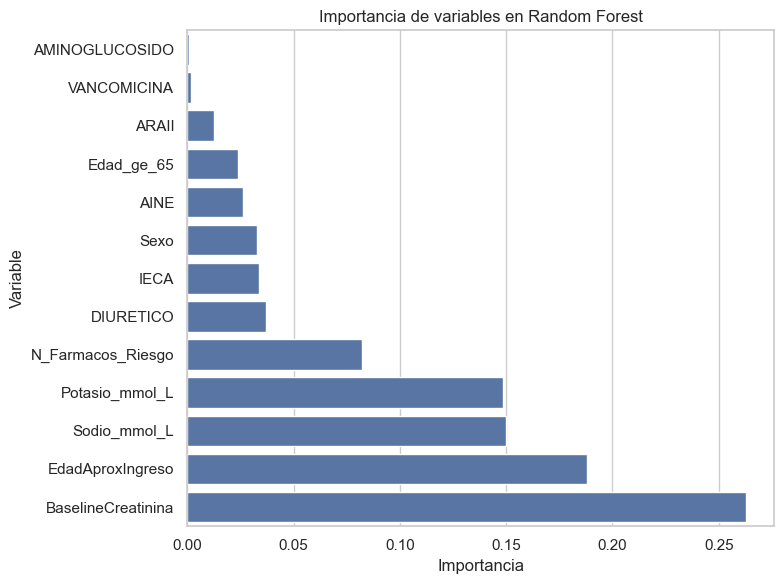

In [17]:
rf_plot_df = rf_importance_df.sort_values(by="Importancia", ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_plot_df, x="Importancia", y="Variable")
plt.title("Importancia de variables en Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_12_rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### 11. Comparación conjunta de variables importantes
Se creó una tabla combinada (`comparison_df`) que reunió, para cada variable:

- coeficiente,
- valor absoluto del coeficiente,
- odds ratio,
- e importancia en Random Forest.

**Justificación**
Esta comparación permitió analizar si existía coherencia entre ambos modelos o si cada uno estaba priorizando conjuntos diferentes de variables.

**Interpretación**
La tabla mostró que:

- `BaselineCreatinina` fue la variable más consistentemente relevante en ambos modelos,
- `EdadAproxIngreso` tuvo gran importancia en Random Forest, aunque un coeficiente pequeño en regresión logística,
- `N_Farmacos_Riesgo` mostró relevancia en ambos enfoques,
- mientras que variables como `IECA` y `AINE` tuvieron gran peso en la regresión logística, pero menor importancia relativa en el Random Forest.

Esta comparación sugiere que los dos modelos captaban aspectos parcialmente distintos del problema, aunque con ciertos puntos de convergencia.


In [18]:
comparison_df = coef_df[["Variable", "Coeficiente", "Abs_Coeficiente", "Odds_Ratio"]].merge(
    rf_importance_df,
    on="Variable"
)

comparison_df.sort_values(by="Importancia", ascending=False)

,Variable,Coeficiente,Abs_Coeficiente,Odds_Ratio,Importancia
2,BaselineCreatinina,0.684896,0.684896,1.983566,0.262868
4,EdadAproxIngreso,0.077839,0.077839,1.080949,0.188128
1,Sodio_mmol_L,-0.019376,0.019376,0.980810,0.149895
0,Potasio_mmol_L,-0.173025,0.173025,0.841117,0.148406
12,N_Farmacos_Riesgo,0.434097,0.434097,1.543569,0.082120
9,DIURETICO,0.142712,0.142712,1.153397,0.036861
7,IECA,1.415263,1.415263,4.117570,0.033576
3,Sexo,-0.955955,0.955955,0.384445,0.032917
6,AINE,1.317561,1.317561,3.734303,0.026390
5,Edad_ge_65,-0.646888,0.646888,0.523673,0.024026


In [16]:
comparison_df.to_csv(f"{RESULTS_DIR}/results_07_model_interpretation_comparison.csv", index=False)

### 12. Visualización comparativa de relevancia
Se generaron gráficos específicos para:

- las variables más importantes según Random Forest
- y las variables con mayor peso absoluto en la regresión logística.

**Justificación**
Estos gráficos permiten visualizar de forma paralela las diferencias de énfasis entre ambos modelos.

**Interpretación**
La comparación visual reforzó una lectura metodológica importante:

- el **Random Forest** priorizó más las variables continuas y fisiológicas,
- la **Regresión Logística** dio mayor peso a ciertas variables farmacológicas y binarias,
- mientras que `BaselineCreatinina` destacó claramente en ambos.



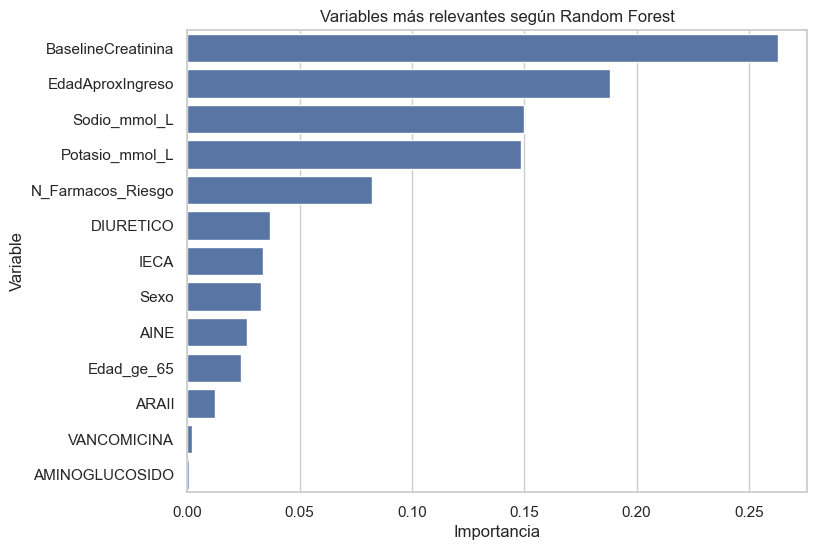

In [19]:
top_rf = rf_importance_df.sort_values(by="Importancia", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_rf, x="Importancia", y="Variable")
plt.title("Variables más relevantes según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

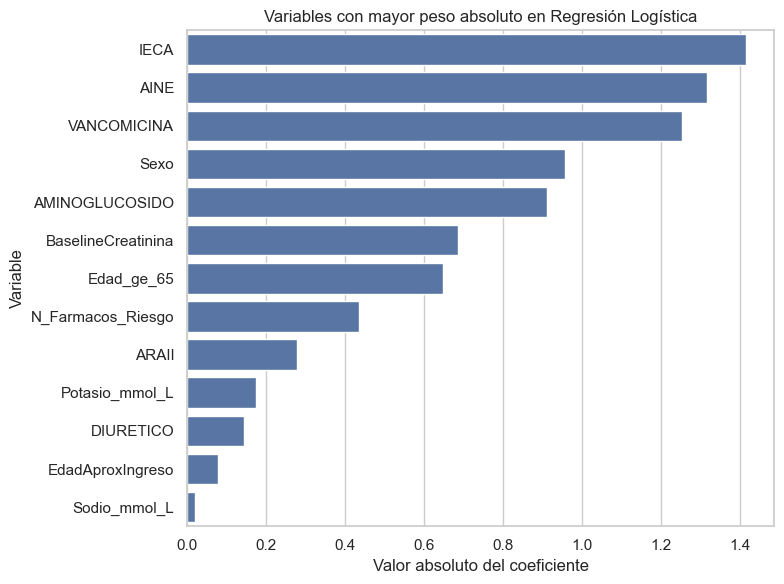

In [20]:
top_logreg = coef_df.sort_values(by="Abs_Coeficiente", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_logreg, x="Abs_Coeficiente", y="Variable")
plt.title("Variables con mayor peso absoluto en Regresión Logística")
plt.xlabel("Valor absoluto del coeficiente")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_13_logreg_abs_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

### 13. Lectura clínica preliminar

La interpretación de este notebook debe realizarse con cautela. Las variables que aparecen como más relevantes en los modelos no deben considerarse causas directas de lesión renal aguda, sino predictores con mayor peso relativo dentro del contexto del dataset y del enfoque de modelado utilizado.

**Interpretación**

La principal conclusión clínica preliminar fue que `BaselineCreatinina` emergió como el predictor más consistente entre ambos modelos, lo que resulta clínicamente plausible dada su relación con el estado renal basal del paciente.

También se observó que:
- la edad tuvo un papel importante, especialmente en el Random Forest,
- la carga farmacológica agregada (`N_Farmacos_Riesgo`) mostró utilidad en ambos modelos,
- y ciertos grupos farmacológicos individuales, como `IECA` y `AINE`, mostraron asociaciones positivas en la regresión logística.

No obstante, estas observaciones deben interpretarse como hallazgos predictivos dentro del modelo, no como evidencia causal ni como inferencias clínicas definitivas.


### 14. Conclusiones del notebook
**Interpretación de modelos**

En este notebook se interpretaron los modelos entrenados desde dos enfoques complementarios:

- la regresión logística, mediante coeficientes y odds ratios,
- y el Random Forest, mediante importancias relativas de variables.

**Hallazgos principales**

- `BaselineCreatinina` fue la variable más consistentemente relevante en ambos modelos,
- el Random Forest otorgó mayor importancia a variables continuas relacionadas con estado fisiológico,
- la regresión logística destacó especialmente algunas exposiciones farmacológicas y variables binarias,
- `N_Farmacos_Riesgo` mostró utilidad en ambos enfoques,
- y la interpretación global sugirió una combinación de señales clínicas relacionadas con función renal basal, edad y exposición farmacológica.

**Conclusión metodológica principal**

La interpretación realizada en este notebook aportó valor al proyecto no por establecer relaciones causales, sino por mostrar qué variables contribuyen de forma más importante a la predicción en esta cohorte concreta y cómo distintos modelos pueden capturar patrones complementarios dentro del mismo problema clínico.
